In [8]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from numba import njit

In [9]:
@njit
def sist_ecs(u,x,t,D=0.5):
    # Ojo este ejemplo no usa explicitamente x y t
    dx = x[1]-x[0]
    Nx = len(u)
    dui = np.zeros_like(u)
    for i in range(1,Nx-1):
        dui[i] = D*( u[i+1] - 2*u[i] + u[i-1] )/dx**2
    return dui

@njit
def RK4_EDP_F1D(f,x,t,f0,D=0.5):
    sol = np.zeros( (len(x),len(t)) )
    dx , dt = x[1]-x[0] , t[1]-t[0]
    r = D*dt/dx**2
    #print('r= ',r)
    if r < 0.5:
        sol[:,0] = f0
        for n in range(len(t)-1):
            k1 = f( sol[:,n] , x , t[n] )
            k2 = f( sol[:,n]+0.5*k1*dt , x , t[n]+0.5*dt )
            k3 = f( sol[:,n]+0.5*k2*dt , x , t[n]+0.5*dt )
            k4 = f( sol[:,n]+k3*dt , x , t[n]+dt )
            sol[:,n+1] =  sol[:,n] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
    else:
        print('No hay convergencia')
    return sol

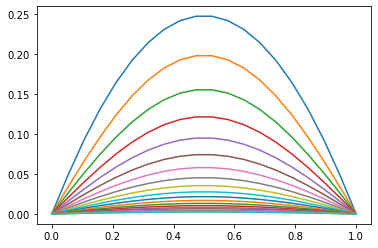

In [10]:
x , t = np.linspace(0,1,20) , np.linspace(0,1,400)
P0 = -x*(x-1)
u_x_t = RK4_EDP_F1D(sist_ecs,x,t,P0)
for i in range(1,len(t),20):
    plt.plot(x,u_x_t[:,i])
plt.show()

In [11]:
%%timeit
u_x_t = RK4_EDP_F1D(sist_ecs,x,t,P0)

194 µs ± 6.38 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [12]:
@njit
def Mat_AB(x,r):
    N = len(x)-2
    A , B = np.zeros((N,N)) , np.zeros((N,N))
    d_A , d_B = 2*(1+r) , 2*(1-r)
    for i in range(N-1):
        A[i,i] , B[i,i] = d_A , d_B
        A[i,i+1] , B[i,i+1] = -r , r
        A[i+1,i] , B[i+1,i] = -r , r
    A[-1,-1] , B[-1,-1] = d_A , d_B
    return A , B

@njit
def Met_CN(x,t,Psi0,D=0.5):
    r = (D*(t[1]-t[0]))/((x[1]-x[0])**2)
    sol = np.zeros( (len(x),len(t)) )
    sol[:,0] = Psi0
    #print('Valor r=',r)
    if r < 1:
        A , B = Mat_AB(x,r)
        A_inv = la.inv(A)
        M_evol = np.dot(A_inv,B)
        for i in range(len(t)-1):
            # Solo evolucionar los puntos interiores
            sol[1:-1,i+1] = np.dot(M_evol,sol[1:-1,i])
    else:
        print('No hay convergencia')
    return sol

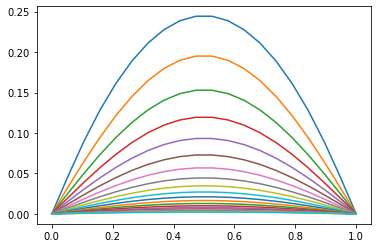

In [14]:
x , t = np.linspace(0,1,20) , np.linspace(0,1,200)
P0 = -x*(x-1)
sol_Psi = Met_CN(x,t,P0)
for i in range(1,200,10):
    plt.plot(x,sol_Psi[:,i])
plt.show()

In [15]:
%%timeit
sol_Psi = Met_CN(x,t,P0)

39.7 µs ± 1.95 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [17]:
512/39.7

12.896725440806044

In [19]:
19.8e3/194

102.0618556701031